# scCS Tutorial — Single-cell Commitment Scores with Radial Star Embedding

**scCS** computes RNA velocity-based commitment scores for k-furcation decisions in single-cell data.

### What scCS does
1. Takes a user-defined **bifurcation cluster** (progenitor) and **k terminal fate clusters**
2. Builds a **radial star embedding** — progenitor at origin, each fate on its own arm
3. Projects **RNA velocity** into this embedding
4. Computes **commitment scores** (unCS, nCS) and per-cell fate affinities
5. Identifies **driver genes** (velocity-based + DEG-based) per fate arm
6. Runs **pathway enrichment** (KEGG, GO BP, Reactome) per fate

### Reference
Kriukov et al. (2025) *Single-cell transcriptome of myeloid cells in response to transplantation of human retinal neurons reveals reversibility of microglial activation*

---

## Contents
1. [Installation](#1-installation)
2. [Quick start with synthetic data](#2-quick-start-synthetic-data)
3. [Real data workflow](#3-real-data-workflow)
4. [Commitment scores](#4-commitment-scores)
5. [Visualizations](#5-visualizations)
6. [Driver genes — velocity-based](#6-driver-genes-velocity-based)
7. [Driver genes — DEG-based](#7-driver-genes-deg-based)
8. [Pathway enrichment](#8-pathway-enrichment)
9. [Export results](#9-export-results)
10. [Advanced: k=3 trifurcation](#10-advanced-k3-trifurcation)


## 1. Installation

In [36]:
# Install from GitHub (recommended)
!pip install git+https://github.com/mcrewcow/scCS.git

# Or from local directory:
# !pip install -e /path/to/scCS

import scCS
print(f"scCS version: {scCS.__version__}")

Obtaining file:///home/baranov_lab/Downloads/scCS_v0.2.2/scCS
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for scCS (pyproject.toml) ... done
  Created wheel for scCS: filename=sccs-0.2.0-0.editable-py3-none-any.whl size=2835 sha256=ccb9dfc43c2f630b3d2f12fa97639706002d0599ed08f514ecdadd8a6673a0a9
  Stored in directory: /tmp/pip-ephem-wheel-cache-uuizpqm3/wheels/f3/41/f8/3988c51cf6b90bd4a265e10437e47638b695c049f42371da25
Successfully built scCS
  Attempting uninstall: scCS
    Found existing installation: scCS 0.2.0
    Uninstalling scCS-0.2.0:
      Successfully uninstalled scCS-0.2.0


## 2. Quick start with synthetic data

We generate a minimal synthetic dataset with:
- 100 progenitor cells (cluster '0') at the bifurcation point
- 150 cells committed to FateA (cluster '1') — velocity pointing East
- 150 cells committed to FateB (cluster '2') — velocity pointing West


In [2]:
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import scCS
import scvelo as scv
import scanpy as sc
adata = scv.datasets.pancreas()


In [3]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/home/baranov_lab/anaconda3/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


In [5]:
sc.pp.neighbors(adata)

In [6]:
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [7]:
scv.tl.recover_dynamics(adata, n_jobs=40)
scv.tl.velocity(adata, mode="dynamical", n_jobs=40)
scv.tl.velocity_graph(adata)

recovering dynamics (using 40/40 cores)


  0%|          | 0/1139 [00:00<?, ?gene/s]

    finished (0:00:31) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/40 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:03) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


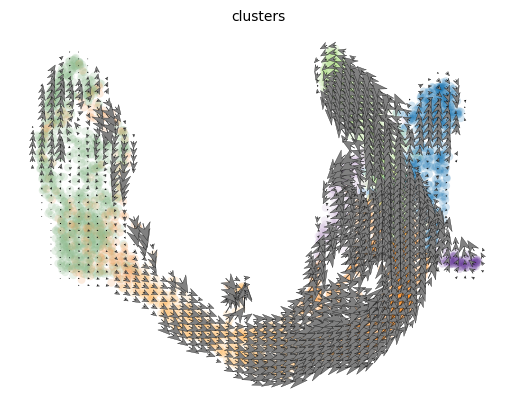

In [8]:
scv.pl.velocity_embedding_grid(adata, color = 'clusters', arrow_size = 6, arrow_length = 4)

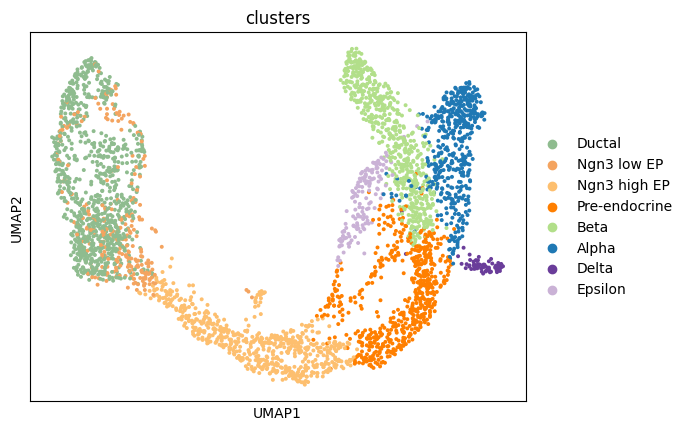

In [9]:
sc.pl.umap(adata, color = 'clusters')

In [10]:
cluster_key = "clusters"   # <-- change to your obs column

color_map = dict(zip(
    adata.obs[cluster_key].cat.categories,
    adata.uns[f"{cluster_key}_colors"],
))
print(color_map)

{'Ductal': '#8fbc8f', 'Ngn3 low EP': '#f4a460', 'Ngn3 high EP': '#fdbf6f', 'Pre-endocrine': '#ff7f00', 'Beta': '#b2df8a', 'Alpha': '#1f78b4', 'Delta': '#6a3d9a', 'Epsilon': '#cab2d6'}


In [11]:
# ── Create CommitmentScorer ────────────────────────────────────────────────
scorer = scCS.CommitmentScorer(
    adata,
    bifurcation_cluster='Pre-endocrine',          # progenitor cluster label
    terminal_cell_types=["Alpha", "Beta",'Epsilon','Delta'],   # terminal fate cluster labels
    cluster_key='clusters',
    n_bins=36,                        # 36 angular bins = 10° each
    sector_mode='centroid',           # anchor sectors to fate centroid directions
)

# ── Build radial star embedding ────────────────────────────────────────────
# Returns adata_sub: subset containing ONLY progenitor + fate cells



In [12]:
scorer.build_embedding(
    differentiation_metric='pseudotime',  # orders cells along each arm
    arm_scale=10.0,                       # max radial distance
    jitter=0.3,                           # perpendicular noise to avoid overplotting
)

print(f"\nSubset shape: {scorer.adata_sub.shape}")
print(f"Embedding shape: {scorer.adata_sub.obsm['X_sccs'].shape}")

[scCS] Building star embedding: bifurcation='Pre-endocrine', k=4 fates, metric='pseudotime'
computing terminal states
    identified 5 regions of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
[scCS] Subsetting: 1876 / 3696 cells kept
       (1820 cells from other populations excluded)
       Alpha: 481 cells (fate)
       Beta: 591 cells (fate)
       Delta: 70 cells (fate)
       Epsilon: 142 cells (fate)
       Pre-endocrine: 592 cells (progenitor)

[scCS] Star embedding built → adata_sub.obsm["X_sccs"] shape: (1876, 2)
       Arm angles: {'Alpha': 0.0, 'Beta': 90.0, 'Epsilon': 180.0, 'Delta': 270.0}
[scCS] Star embedding stored in scorer.adata_sub.obsm['X_sccs']. (1876 cells)

Subset shape: (1876, 2000)
Embedding shape: (1876, 2)


In [13]:
adata

AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'log1p', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'loss'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u'
    obsp: 'distances', 'con

In [14]:
scorer.fit()

[scCS] Bifurcation cluster 'Pre-endocrine': 592 cells, centroid=(-0.00, -0.00)
[scCS]   Fate 'Alpha': 481 cells, centroid=(9.24, -0.01)
[scCS]   Fate 'Beta': 591 cells, centroid=(0.03, 8.04)
[scCS]   Fate 'Epsilon': 142 cells, centroid=(-9.46, -0.02)
[scCS]   Fate 'Delta': 70 cells, centroid=(-0.05, -9.75)
[scCS] FateMap built: k=4 fates
[scCS] Projecting velocity via scVelo on full adata → slicing to subset...
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_sccs_tmp', embedded velocity vectors (adata.obsm)
[scCS] Velocity projected. Shape: (1876, 2)
FateMap  (bifurcation_cluster='Pre-endocrine', k=4)
  Cluster key : 'clusters'
  Root cells  : 592
  Root centroid: (-0.005, -0.003)
  Fate 0: 'Alpha'  n_cells=481  centroid=(9.24, -0.01)  arm_angle=0.0°
  Fate 1: 'Beta'  n_cells=591  centroid=(0.03, 8.04)  arm_angle=90.0°
  Fate 2: 'Epsilon'  n_cells=142  centroid=(-9.46, -0.02)  arm_angle=180.0°
  Fate 3: 'Delta'  n_cells=70  centroid=(-0.05, -9.75)  arm_angle

## 4. Commitment scores

In [15]:
# ── Compute commitment scores ──────────────────────────────────────────────
result = scorer.score(compute_cell_level=True)

# result contains:
#   result.pairwise_nCS   — normalized commitment score matrix (k x k)
#   result.pairwise_unCS  — unnormalized commitment score matrix (k x k)
#   result.commitment_vector  — normalized fate probabilities
#   result.commitment_entropy — Shannon entropy (0=committed, 1=uncertain)
#   result.cell_scores    — per-cell fate affinities (n_cells x k)
#   result.M_sector       — cumulative velocity magnitude per fate sector

print(result.summary())


=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Epsilon, Delta
  Dominant fate: Beta
  Commitment entropy (normalized): 0.9003

  Commitment vector (normalized):
    Alpha: 0.2878
    Beta: 0.4474
    Epsilon: 0.1596
    Delta: 0.1052

  Pairwise nCS matrix:
            Alpha      Beta   Epsilon     Delta
Alpha    1.000000  0.790400  0.532491  0.398282
Beta     1.265183  1.000000  0.673699  0.503900
Epsilon  1.877965  1.484343  1.000000  0.747961
Delta    2.510781  1.984520  1.336969  1.000000
=== CommitmentScoreResult ===
  Fates (4): Alpha, Beta, Epsilon, Delta
  Dominant fate: Beta
  Commitment entropy (normalized): 0.9003

  Commitment vector (normalized):
    Alpha: 0.2878
    Beta: 0.4474
    Epsilon: 0.1596
    Delta: 0.1052

  Pairwise nCS matrix:
            Alpha      Beta   Epsilon     Delta
Alpha    1.000000  0.790400  0.532491  0.398282
Beta     1.265183  1.000000  0.673699  0.503900
Epsilon  1.877965  1.484343  1.000000  0.747961
Delta    2.510781  1.984520  1.336

In [16]:
# ── Pairwise CS as DataFrame ───────────────────────────────────────────────
print("Pairwise nCS matrix:")
print(result.pairwise_to_dataframe(normalized=True).round(3))

print("\nPairwise unCS matrix:")
print(result.pairwise_to_dataframe(normalized=False).round(3))

print("\nFate summary:")
print(result.to_dataframe())


Pairwise nCS matrix:
         Alpha   Beta  Epsilon  Delta
Alpha    1.000  0.790    0.532  0.398
Beta     1.265  1.000    0.674  0.504
Epsilon  1.878  1.484    1.000  0.748
Delta    2.511  1.985    1.337  1.000

Pairwise unCS matrix:
         Alpha   Beta  Epsilon  Delta
Alpha    1.000  0.643    1.804  2.737
Beta     1.555  1.000    2.804  4.254
Epsilon  0.554  0.357    1.000  1.517
Delta    0.365  0.235    0.659  1.000

Fate summary:
      fate    M_sector  n_cells  commitment_fraction
0    Alpha   80.449879    481.0             0.287826
1     Beta  125.060780    591.0             0.447431
2  Epsilon   44.602195    142.0             0.159574
3    Delta   29.395929     70.0             0.105170


## 5. Visualizations

### 5.1 Star embedding — primary visualization


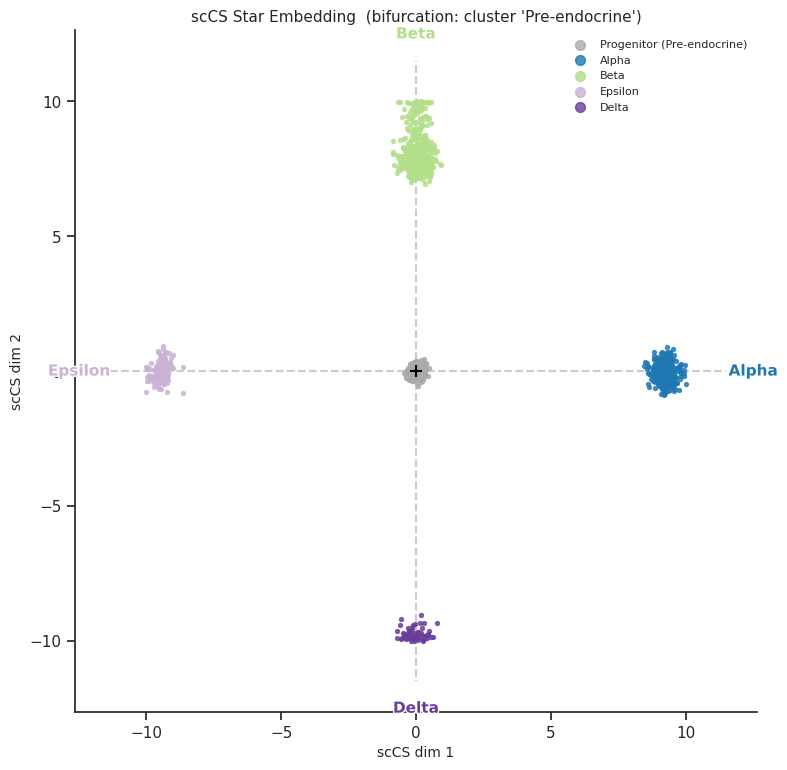

In [17]:
# ── Star embedding: colored by fate arm ───────────────────────────────────
fig = scorer.plot_star(
    result,
    color_by="fate",
    color_map = color_map, # <-- preserves your original cluster colors
    point_size=8,
    alpha=0.8,
)
plt.show()


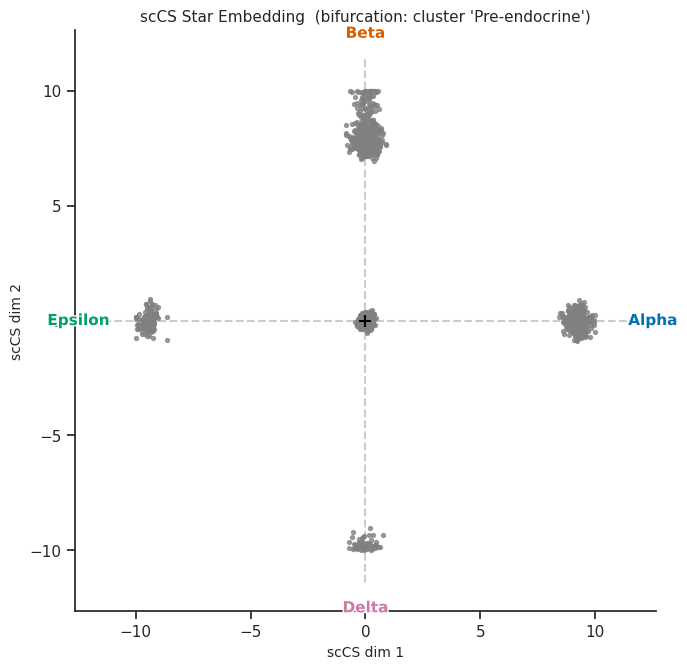

In [18]:
# ── Star embedding: colored by pseudotime ─────────────────────────────────
fig = scorer.plot_star(result, color_by='pseudotime', figsize=(7, 7))
plt.show()


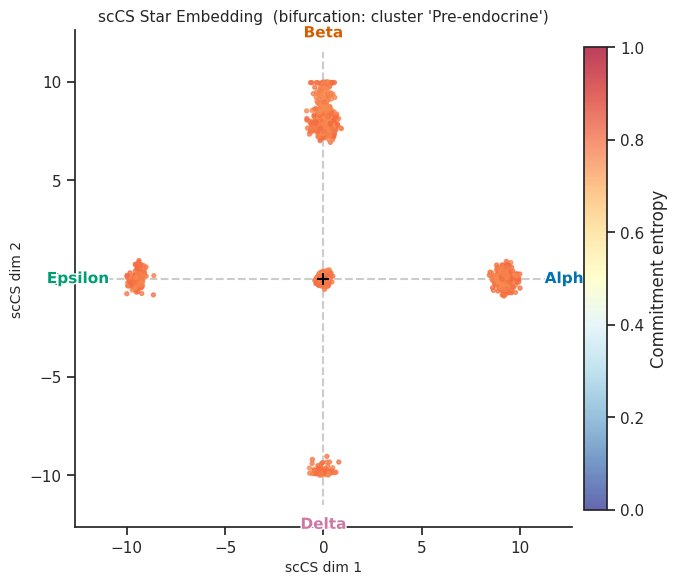

In [19]:
# ── Star embedding: colored by commitment entropy ─────────────────────────
# High entropy = cell is uncertain about its fate
fig = scorer.plot_star(result, color_by='entropy', figsize=(7, 7))
plt.show()


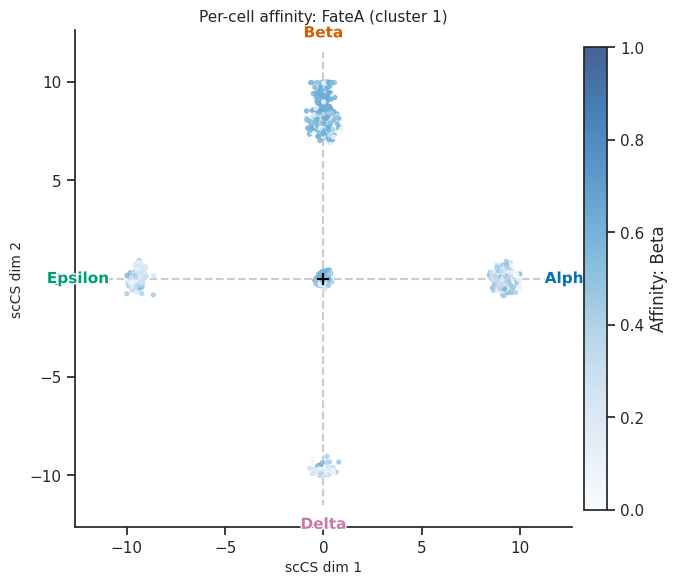

In [20]:
# ── Star embedding: colored by per-cell affinity for FateA ───────────────
fig = scorer.plot_star(result, color_by='Beta', figsize=(7, 7),
                       title='Per-cell affinity: FateA (cluster 1)')
plt.show()


### 5.2 Multi-panel star embedding

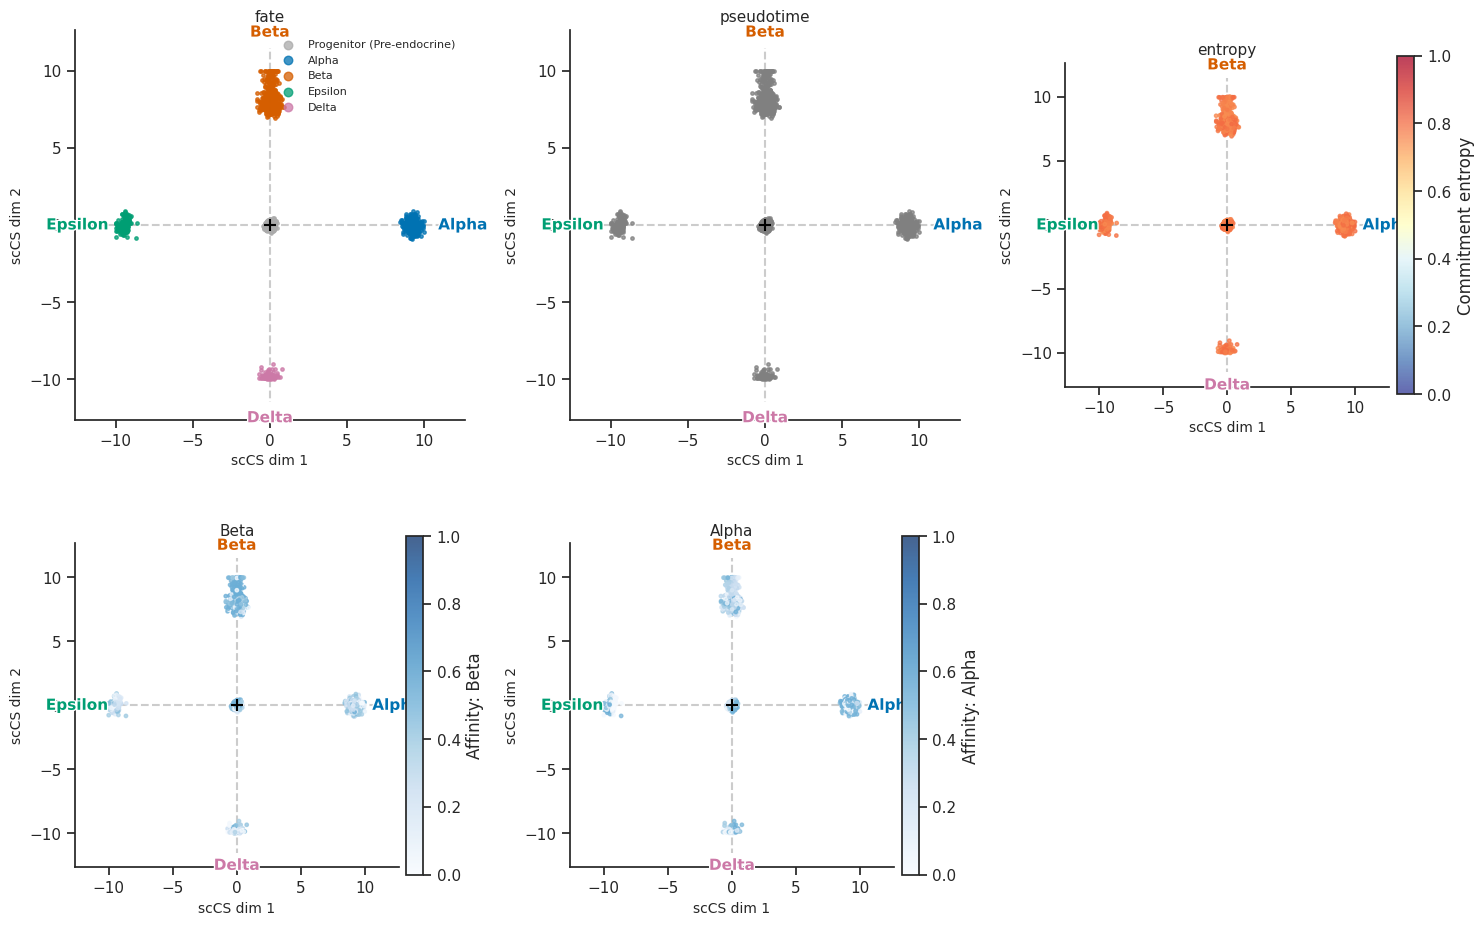

In [21]:
# ── All panels at once ────────────────────────────────────────────────────
fig = scCS.plot_star_panels(
    scorer.adata_sub, result,
    panels=['fate', 'pseudotime', 'entropy', 'Beta', 'Alpha'],
    figsize_per_panel=(5, 5),
)
plt.show()


### 5.3 Rose plot — velocity magnitude by direction

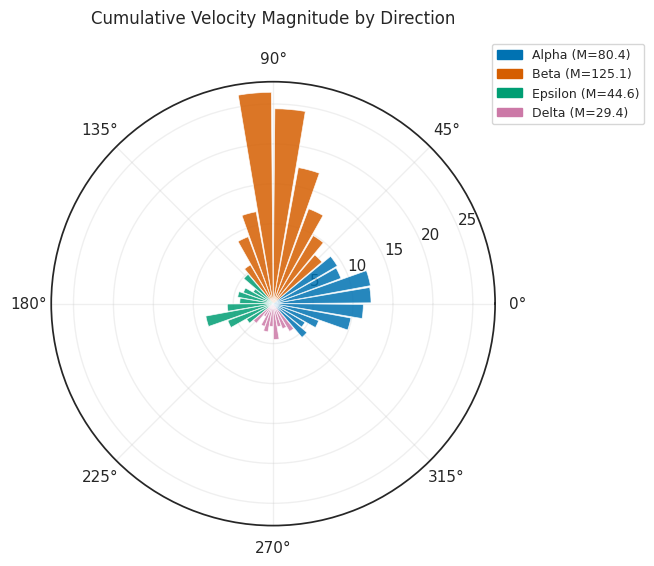

In [22]:
fig = scorer.plot_rose(result)
plt.show()


### 5.4 Pairwise CS heatmap

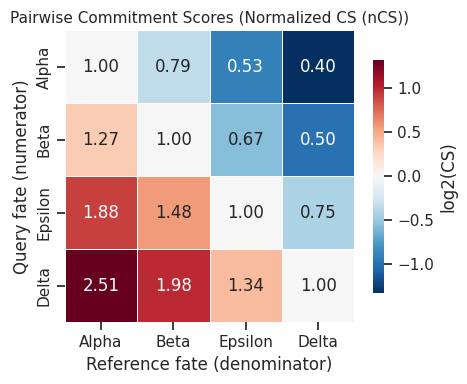

In [23]:
fig = scorer.plot_pairwise_cs(result, normalized=True)
plt.show()


### 5.5 Commitment bar chart

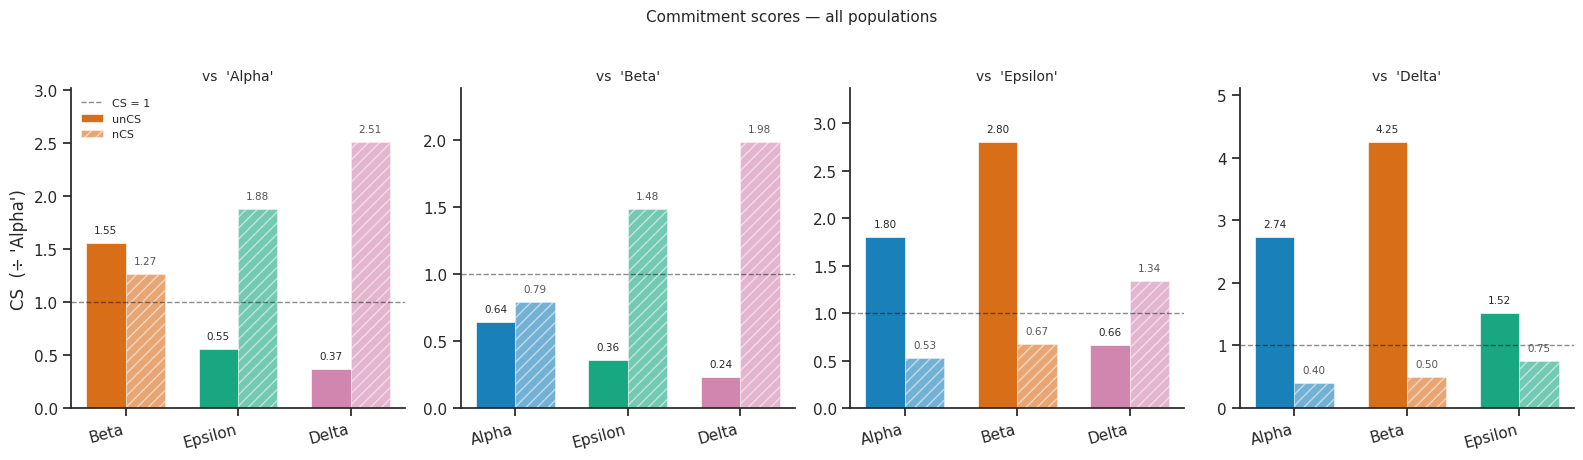

In [24]:
fig = scorer.plot_commitment_bar(result)
plt.show()


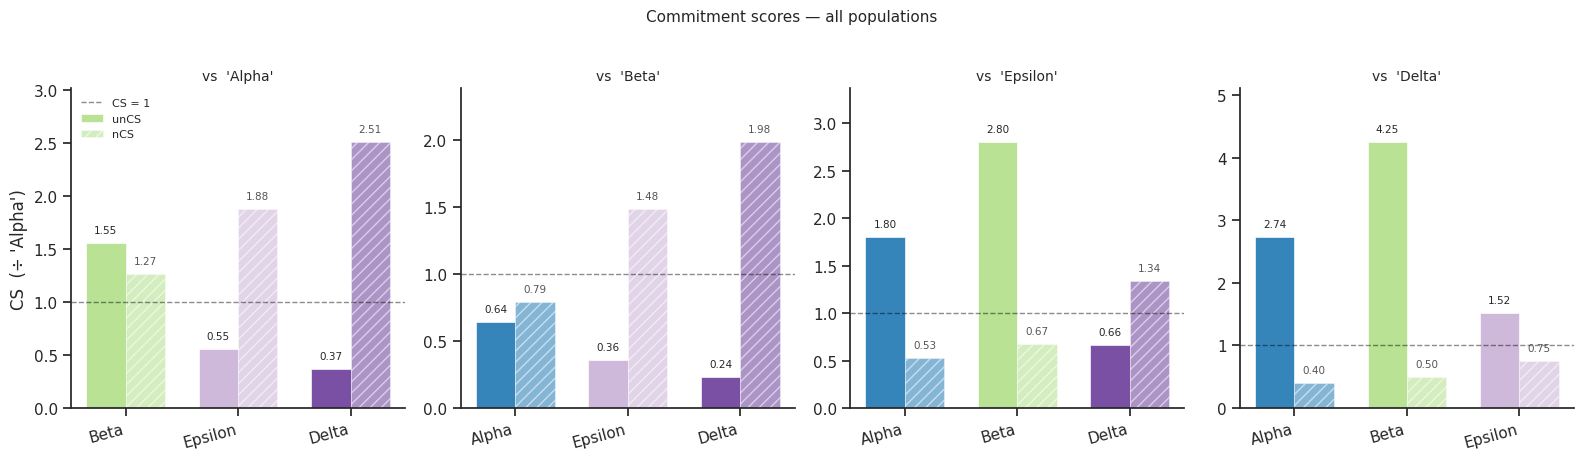

In [25]:
fig = scorer.plot_commitment_bar(
    result,
    color_map=color_map,        # bars colored by fate
    # reference_fate="Homeostatic",  # optional override
)
plt.show()

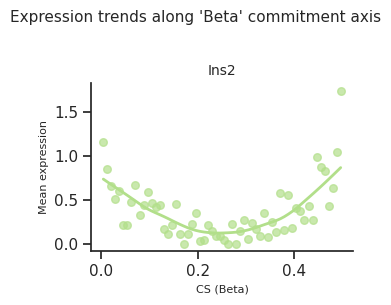

In [40]:
# CellRank-style: cells binned by per-cell CS for a chosen fate,
# mean expression per bin plotted with LOWESS smooth.
# Requires compute_cell_level=True (Cell 2 above).

genes_of_interest = ["Ins2"]   # <-- your genes

fig = scCS.plot_expression_trends(
    adata,
    result,
    genes=genes_of_interest,
    fate=result.dominant_fate,   # or e.g. fate="Activated"
    n_bins=60,                   # bins along CS axis
    layer=None,             # or None to use adata.X
    smooth=True,
    smooth_frac=0.4,             # LOWESS bandwidth (0–1)
    color_map=color_map,
    ncols=2,
)
plt.show()


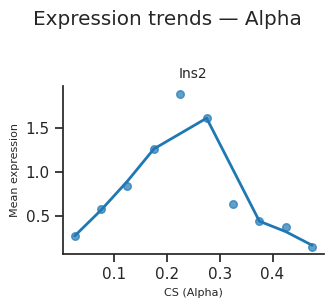

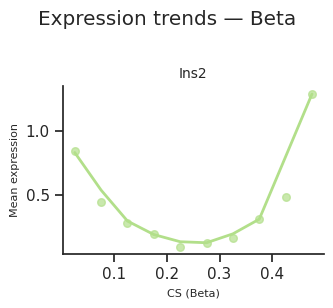

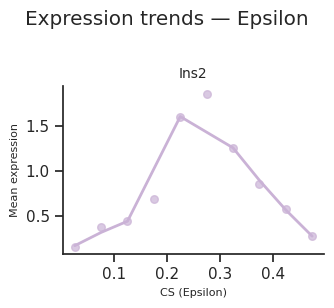

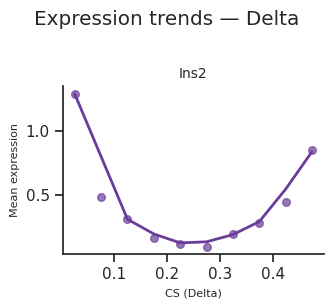

In [42]:
for fate_name in result.fate_names:
    fig = scCS.plot_expression_trends(
        adata, result,
        genes=genes_of_interest,
        fate=fate_name,
        color_map=color_map,
        ncols=4,
    )
    fig.suptitle(f"Expression trends — {fate_name}", y=1.02)
    fig.savefig(f"expression_trends_{fate_name}.svg", bbox_inches="tight")

### 5.6 Per-cell fate affinity heatmap

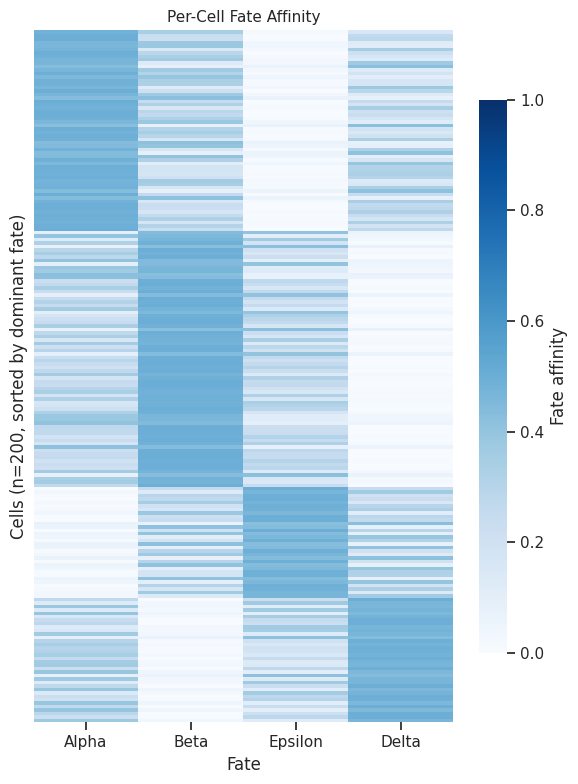

In [32]:
fig = scorer.plot_commitment_heatmap(result, max_cells=200)
plt.show()


## 6. Driver genes — velocity-based

Ranks genes by their mean scVelo velocity in each fate arm's cells.
**High positive velocity** = gene is being actively upregulated along that fate.

Requires the `'velocity'` layer (from scVelo pipeline).


In [33]:


# ── Get velocity-based driver genes ───────────────────────────────────────
vel_drivers = scorer.get_velocity_drivers(n_top=10)



── Velocity drivers: Alpha (top 10) ──
 rank   gene  mean_velocity
    1    Clu       1.532060
    2  Pcsk2       1.510375
    3 Cryba2       1.217163
    4 Btbd17       0.930656
    5   Pax6       0.899398
    6   Cpa2       0.851096
    7  Glud1       0.671610
    8  Meis2       0.663538
    9 Atp1b1       0.652560
   10  Map1b       0.631372

── Velocity drivers: Beta (top 10) ──
 rank    gene  mean_velocity
    1    Gnas       4.182460
    2    Nnat       4.043847
    3    Ins2       3.689224
    4     Clu       1.648854
    5 Ppp1r1a       1.526693
    6   Pcsk2       1.144430
    7    Isl1       1.070216
    8  Tmem27       0.972911
    9     Cpe       0.927952
   10    Pax6       0.885163

── Velocity drivers: Epsilon (top 10) ──
 rank   gene  mean_velocity
    1 Cryba2       1.469567
    2    Clu       1.337410
    3  Pcsk2       1.254354
    4   Dlk1       1.125737
    5  Meis2       1.050371
    6   Cpa2       0.953895
    7   Pax6       0.936360
    8    Cpe       0.917734


In [34]:
# ── Access results as DataFrames ──────────────────────────────────────────
for fate_name, df in vel_drivers.items():
    print(f"\n=== Velocity drivers: {fate_name} ===")
    print(df.head(10)[['rank', 'gene', 'mean_velocity']].to_string(index=False))



=== Velocity drivers: Alpha ===
 rank   gene  mean_velocity
    1    Clu       1.532060
    2  Pcsk2       1.510375
    3 Cryba2       1.217163
    4 Btbd17       0.930656
    5   Pax6       0.899398
    6   Cpa2       0.851096
    7  Glud1       0.671610
    8  Meis2       0.663538
    9 Atp1b1       0.652560
   10  Map1b       0.631372

=== Velocity drivers: Beta ===
 rank    gene  mean_velocity
    1    Gnas       4.182460
    2    Nnat       4.043847
    3    Ins2       3.689224
    4     Clu       1.648854
    5 Ppp1r1a       1.526693
    6   Pcsk2       1.144430
    7    Isl1       1.070216
    8  Tmem27       0.972911
    9     Cpe       0.927952
   10    Pax6       0.885163

=== Velocity drivers: Epsilon ===
 rank   gene  mean_velocity
    1 Cryba2       1.469567
    2    Clu       1.337410
    3  Pcsk2       1.254354
    4   Dlk1       1.125737
    5  Meis2       1.050371
    6   Cpa2       0.953895
    7   Pax6       0.936360
    8    Cpe       0.917734
    9  Syt13       0.

## 7. Driver genes — DEG-based

Wilcoxon rank-sum test: each fate arm vs the bifurcation (progenitor) cluster.
Returns logFC and adjusted p-value per gene.

- **Up-regulated** (logFC > 0.25, padj < 0.05): genes gained along this fate
- **Down-regulated** (logFC < -0.25, padj < 0.05): genes lost along this fate


In [35]:
# ── DEG-based driver genes ────────────────────────────────────────────────
deg_drivers = scorer.get_deg_drivers(
    n_top=20,
    pval_cutoff=0.05,
    logfc_cutoff=0.25,
)



── DEG drivers: Alpha vs progenitor ──
   Significant: 674  (up: 342, down: 332)
         gene  logfoldchange      pval_adj
          Tnr      26.089581  3.098266e-02
        Hpgds      26.065168  4.154484e-02
          Gcg       7.436105  1.094783e-63
         Dpp4       5.570946  1.771928e-19
         Iapp       5.407356  3.049435e-99
        Tgfb2       5.169394  9.429912e-03
      Ppp1r1a       4.793208  6.292389e-30
       Pou6f2       4.755236  4.117515e-06
      Slc30a8       4.721995  2.554414e-21
          Pyy       4.619513  9.848005e-94
        G6pc2       4.546682  5.441696e-04
       Tmem27       4.525331 1.123328e-141
       Slc7a2       4.293180  3.611417e-23
      Ripply3       4.255744  1.331553e-20
         Asb4       4.207607  2.290050e-14
       Sorcs2       4.165565  6.301536e-03
      Tmsb15l       4.129451  2.484079e-73
        Rab37       4.113585  3.082511e-24
         Wnk3       4.047694  1.968993e-31
G630016G05Rik       3.918338  5.112363e-03

── DEG drivers

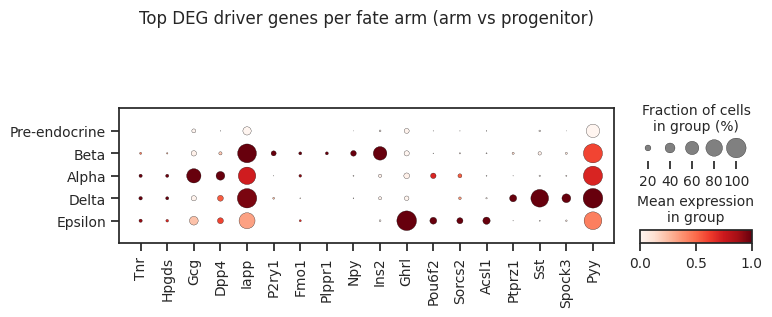

In [34]:
# ── Visualize: dot plot of top DEG drivers ────────────────────────────────
import scanpy as sc

# Collect top significant genes across all fates
top_genes = []
for fate_name, df in deg_drivers.items():
    sig = df[df['significant']]
    top_genes += sig.head(5)['gene'].tolist()
top_genes = list(dict.fromkeys(top_genes))  # deduplicate, preserve order

if top_genes:
    sc.pl.dotplot(
        scorer.adata_sub, top_genes,
        groupby='clusters',
        title='Top DEG driver genes per fate arm (arm vs progenitor)',
        standard_scale='var',
    )
else:
    print("No significant DEGs found at current thresholds.")
    print("(Expected with synthetic data — use real data for meaningful results)")


In [35]:
# ── Intersection: genes significant in BOTH velocity and DEG analyses ─────
for fate_name in scorer.fate_map.fate_names:
    if fate_name not in vel_drivers or fate_name not in deg_drivers:
        continue

    vel_top = set(vel_drivers[fate_name].head(50)['gene'])
    deg_sig = set(deg_drivers[fate_name][deg_drivers[fate_name]['significant']]['gene'])

    intersection = vel_top & deg_sig
    print(f"\n{fate_name}: {len(intersection)} genes in both velocity top-50 and DEG significant")
    if intersection:
        print(f"  Genes: {sorted(intersection)}")



Alpha: 37 genes in both velocity top-50 and DEG significant
  Genes: ['Akr1c19', 'Alcam', 'Ank', 'Atp1b1', 'BC023829', 'Btbd17', 'Cd200', 'Celf3', 'Clu', 'Cryba2', 'Csrp2', 'Dlk1', 'Emb', 'Gars', 'Gch1', 'Glud1', 'Gspt1', 'Immp1l', 'Lurap1l', 'Maged2', 'Map1b', 'Meis2', 'Papss2', 'Pcsk2', 'Pdk3', 'Pdx1', 'Pim2', 'Ppp1r14a', 'Rgs17', 'Smarca1', 'Smarcd2', 'Sox9', 'Spc25', 'Tm4sf4', 'Top1', 'Trp53i13', 'Wnk3']

Beta: 43 genes in both velocity top-50 and DEG significant
  Genes: ['1700086L19Rik', 'Arhgap36', 'BC023829', 'Clu', 'Cpe', 'Dbn1', 'Dlk1', 'Emb', 'Ghr', 'Glud1', 'Gnas', 'Gng12', 'Igfbpl1', 'Ins2', 'Isl1', 'Krt7', 'Lurap1l', 'Map1b', 'Meis2', 'Nnat', 'Olfm1', 'Papss2', 'Pax4', 'Pax6', 'Pcsk2', 'Pdx1', 'Peg10', 'Pim2', 'Ppp1r14a', 'Ppp1r1a', 'Ptprn', 'Rgs17', 'S100a10', 'Scg3', 'Slc30a8', 'Smarcd2', 'Sox9', 'Spc25', 'Syt13', 'Tm4sf4', 'Tmem27', 'Tspan7', 'Wnk3']

Epsilon: 24 genes in both velocity top-50 and DEG significant
  Genes: ['Akap17b', 'Ank', 'Auts2', 'Cdkn1c', 'Clu', 'C

## 8. Pathway enrichment

Runs Enrichr ORA on up- and down-regulated DEG driver genes for each fate arm.

**Gene sets (mouse):**
- `KEGG_2019_Mouse`
- `GO_Biological_Process_2021`
- `Reactome_2022`

**Gene sets (human):**
- `KEGG_2021_Human`
- `GO_Biological_Process_2021`
- `Reactome_2022`

Requires `gseapy >= 1.0`: `pip install gseapy`



  Pathway enrichment: Alpha
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 342
  Down-regulated genes: 332

  [up] Significant terms: 60
                  Gene_set                                                         Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                                    Thyroid hormone synthesis   10/73          0.000097
           KEGG_2019_Mouse                  Protein processing in endoplasmic reticulum  14/163          0.000097
           KEGG_2019_Mouse                                                     Lysosome  11/124          0.000716
             Reactome_2022     Response To Elevated Platelet Cytosolic Ca2+ R-HSA-76005  12/130          0.000786
             Reactome_2022                          Platelet Degranulation R-HSA-114608  12/125          0.000786
             Reactome_2022    Regulation Of RUNX1 Expression And Activity R-HSA-8934593    5/17          0.001593
GO_Biol

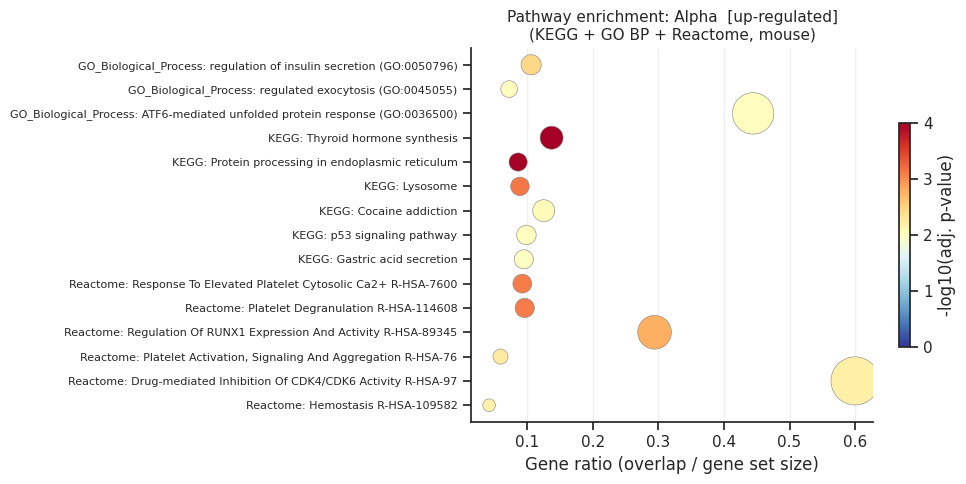

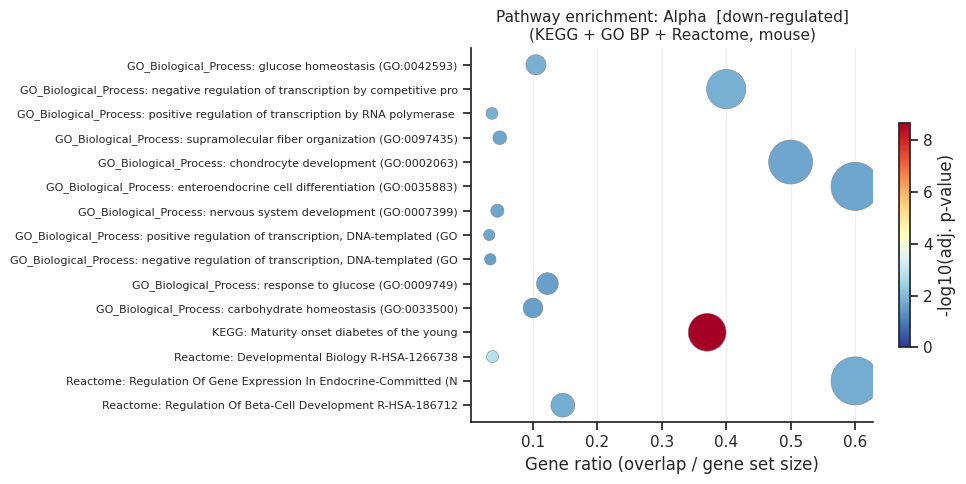


  Pathway enrichment: Beta
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 381
  Down-regulated genes: 326

  [up] Significant terms: 113
                  Gene_set                                                 Term Overlap  Adjusted P-value
           KEGG_2019_Mouse          Protein processing in endoplasmic reticulum  20/163      9.838890e-09
GO_Biological_Process_2021         regulation of insulin secretion (GO:0050796)  16/104      2.686138e-07
           KEGG_2019_Mouse                                    Insulin secretion   13/86      1.007140e-06
             Reactome_2022         Unfolded Protein Response (UPR) R-HSA-381119   13/89      9.419870e-06
           KEGG_2019_Mouse                            Thyroid hormone synthesis   11/73      9.795743e-06
GO_Biological_Process_2021 regulation of peptide hormone secretion (GO:0090276)   12/74      1.145074e-05
GO_Biological_Process_2021         regulation of protein secret

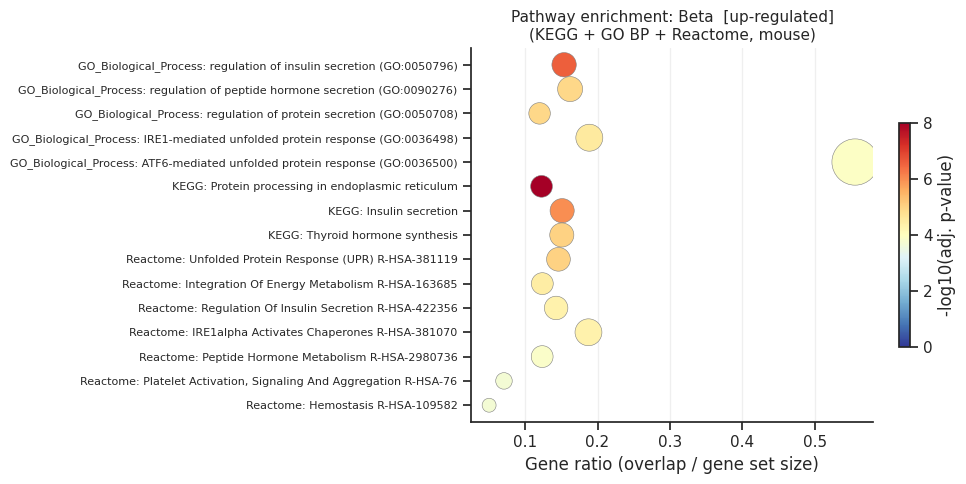

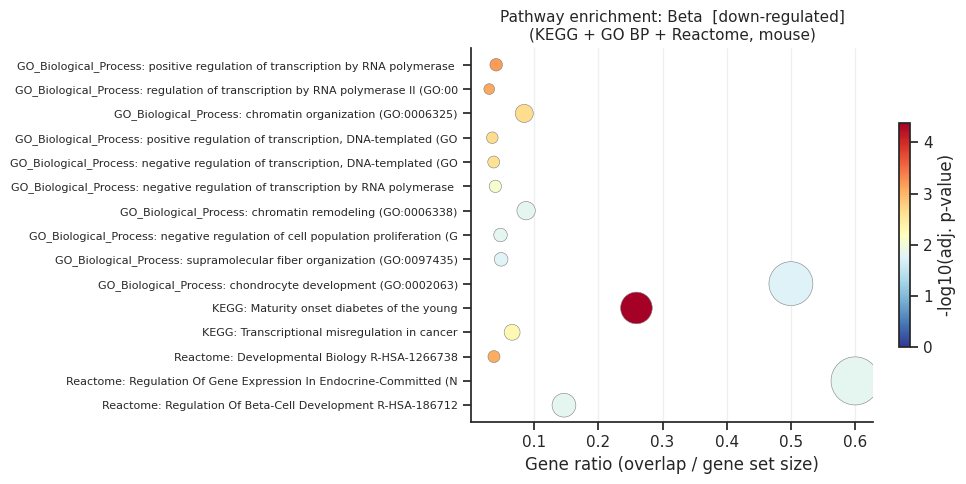


  Pathway enrichment: Epsilon
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 245
  Down-regulated genes: 209

  [up] Significant terms: 41
       Gene_set                                                                                      Term Overlap  Adjusted P-value
KEGG_2019_Mouse                                               Protein processing in endoplasmic reticulum  15/163      3.476931e-07
  Reactome_2022                                                  Peptide Hormone Metabolism R-HSA-2980736   10/89      7.340486e-05
  Reactome_2022 Aberrant Regulation Of Mitotic G1/S Transition In Cancer Due To RB1 Defects R-HSA-9659787    5/17      3.864885e-04
  Reactome_2022                                                       Platelet Degranulation R-HSA-114608  10/125      5.808490e-04
  Reactome_2022                                  Response To Elevated Platelet Cytosolic Ca2+ R-HSA-76005  10/130      6.203054e-04
  Reactome_

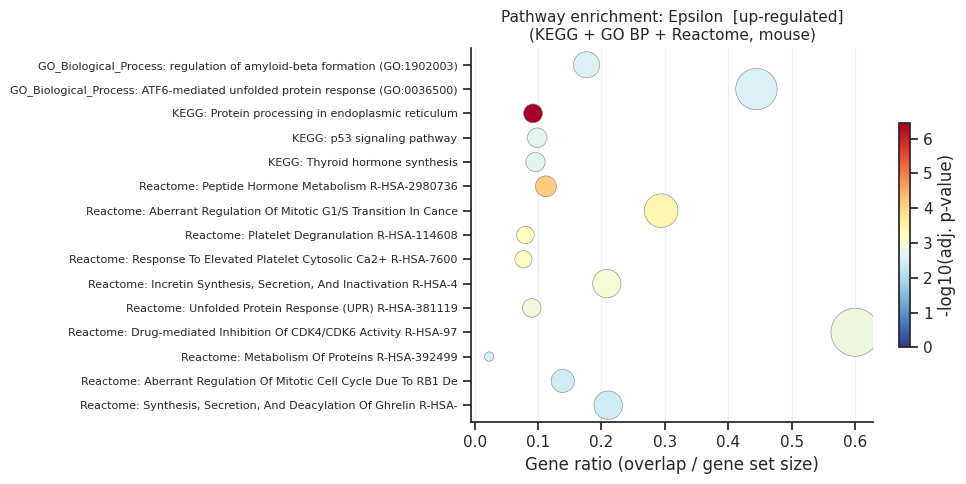

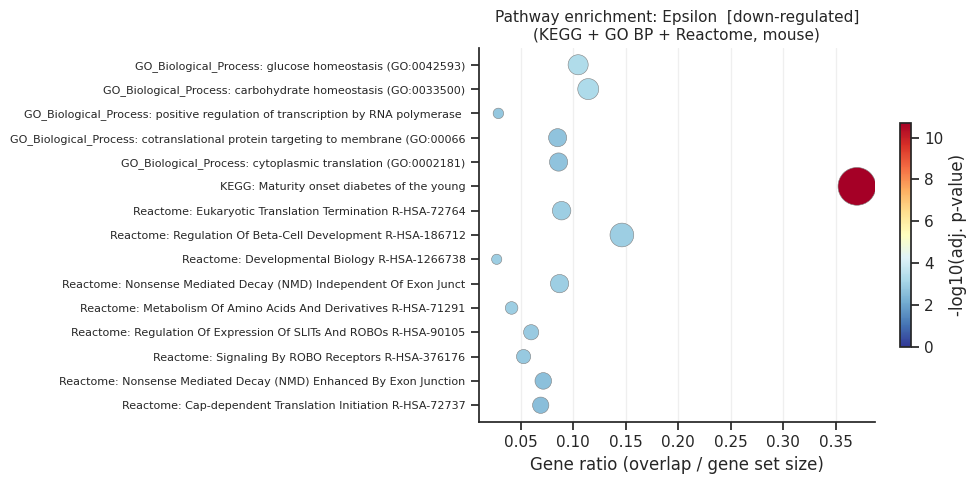


  Pathway enrichment: Delta
  Gene sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'Reactome_2022']
  Up-regulated genes  : 145
  Down-regulated genes: 192

  [up] Significant terms: 28
                  Gene_set                                                                      Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                               Protein processing in endoplasmic reticulum  13/163      3.491309e-08
           KEGG_2019_Mouse                                                 Thyroid hormone synthesis    8/73      5.023692e-06
GO_Biological_Process_2021                      ATF6-mediated unfolded protein response (GO:0036500)     4/9      3.947693e-04
             Reactome_2022                                       Metabolism Of Proteins R-HSA-392499 32/1890      1.596669e-03
           KEGG_2019_Mouse                                                     Circadian entrainment    6/99      4.973554e-03
           KEGG_2019_Mouse                 

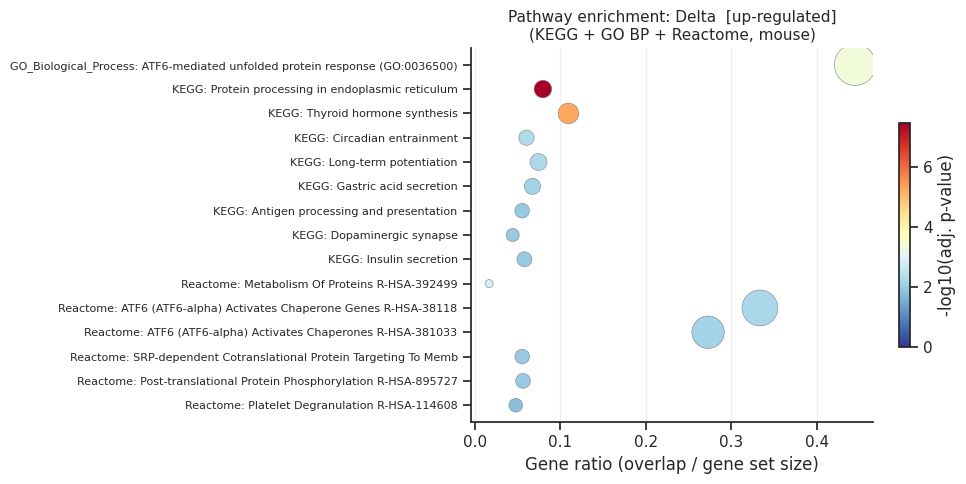

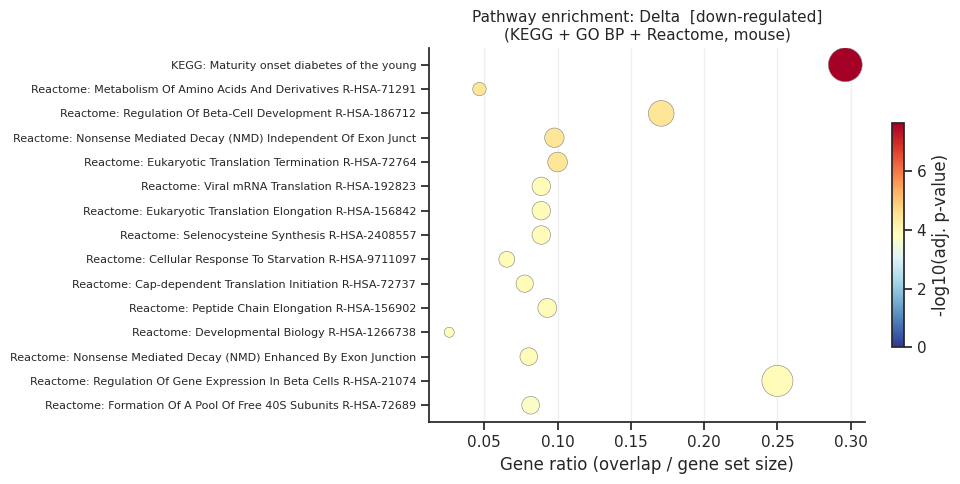


Alpha [up]: 60 significant terms
          Gene_set                                               Term Overlap  \
0  KEGG_2019_Mouse                          Thyroid hormone synthesis   10/73   
1  KEGG_2019_Mouse        Protein processing in endoplasmic reticulum  14/163   
2  KEGG_2019_Mouse                                           Lysosome  11/124   
3    Reactome_2022  Response To Elevated Platelet Cytosolic Ca2+ R...  12/130   
4    Reactome_2022                Platelet Degranulation R-HSA-114608  12/125   

   Adjusted P-value  
0          0.000097  
1          0.000097  
2          0.000716  
3          0.000786  
4          0.000786  

Alpha [down]: 24 significant terms
                     Gene_set  \
0             KEGG_2019_Mouse   
1               Reactome_2022   
2  GO_Biological_Process_2021   
3  GO_Biological_Process_2021   
4  GO_Biological_Process_2021   

                                                Term  Overlap  \
0               Maturity onset diabetes of the 

In [33]:
# ── Pathway enrichment ────────────────────────────────────────────────────
# Note: requires gseapy and internet access for Enrichr API
# Results will be empty with synthetic data (too few significant DEGs)

try:
    enrichment = scorer.get_enrichment(
        deg_drivers,
        organism='mouse',          # 'mouse' or 'human'
        pval_cutoff=0.05,
        logfc_cutoff=0.25,
        plot=True,                 # generate dot plots automatically
        n_top_terms=15,            # top N terms per fate per direction
    )

    # Access results
    for fate_name, fate_results in enrichment.items():
        for direction in ['up', 'down']:
            df = fate_results.get(direction, None)
            if df is not None and not df.empty:
                print(f"\n{fate_name} [{direction}]: {len(df)} significant terms")
                print(df[['Gene_set', 'Term', 'Overlap', 'Adjusted P-value']].head(5))

except ImportError:
    print("gseapy not installed. Run: pip install gseapy")
except Exception as e:
    print(f"Enrichment skipped: {e}")
    print("(Expected with synthetic data — use real data for meaningful results)")


In [34]:
# ── Custom gene sets ──────────────────────────────────────────────────────
# You can specify any Enrichr library:
# https://maayanlab.cloud/Enrichr/#libraries

custom_gene_sets = [
    'KEGG_2019_Mouse',
    'GO_Biological_Process_2021',
    'GO_Molecular_Function_2021',
    'Reactome_2022',
    'WikiPathway_2021_Mouse',
]

# enrichment = scorer.get_enrichment(
#     deg_drivers,
#     gene_sets=custom_gene_sets,
#     organism='mouse',
# )
print("Custom gene sets configured (commented out to avoid API call with synthetic data).")
print(f"Available sets: {custom_gene_sets}")


Custom gene sets configured (commented out to avoid API call with synthetic data).
Available sets: ['KEGG_2019_Mouse', 'GO_Biological_Process_2021', 'GO_Molecular_Function_2021', 'Reactome_2022', 'WikiPathway_2021_Mouse']


## 9. Export results

In [ ]:
import os
os.makedirs('scCS_results', exist_ok=True)

# ── Commitment score summary ───────────────────────────────────────────────
result.to_dataframe().to_csv('scCS_results/commitment_summary.csv', index=False)
result.pairwise_to_dataframe(normalized=True).to_csv('scCS_results/pairwise_nCS.csv')
result.pairwise_to_dataframe(normalized=False).to_csv('scCS_results/pairwise_unCS.csv')

# ── Per-cell scores ────────────────────────────────────────────────────────
cell_score_cols = ['leiden', 'velocity_pseudotime', 'sccs_arm_name',
                   'cs_1', 'cs_2', 'cs_dominant_fate', 'cs_entropy']
cell_score_cols = [c for c in cell_score_cols if c in scorer.adata_sub.obs.columns]
scorer.adata_sub.obs[cell_score_cols].to_csv('scCS_results/cell_scores.csv')

# ── Velocity driver genes ──────────────────────────────────────────────────
for fate_name, df in vel_drivers.items():
    safe = fate_name.replace(' ', '_').replace('/', '_')
    df.to_csv(f'scCS_results/velocity_drivers_{safe}.csv', index=False)

# ── DEG driver genes ───────────────────────────────────────────────────────
for fate_name, df in deg_drivers.items():
    safe = fate_name.replace(' ', '_').replace('/', '_')
    df.to_csv(f'scCS_results/deg_drivers_{safe}.csv', index=False)

# ── Enrichment tables (if available) ──────────────────────────────────────
# scCS.export_enrichment_tables(enrichment, output_dir='scCS_results')

print("Results saved to scCS_results/")
import glob
for f in sorted(glob.glob('scCS_results/*.csv')):
    size = os.path.getsize(f)
    print(f"  {f}  ({size} bytes)")


In [ ]:
Update the package please by

Including unCS/CS plot
Preserving the fate colors of the original population (besides progenitor - keep it gray)
Add Cellrank styled expression plots - where every fate cell is plotted across pseudotime vs gene expression. I need to provide the gene I want to plot manually

## API Reference

### CommitmentScorer

```python
scorer = scCS.CommitmentScorer(
    adata,
    bifurcation_cluster,    # str: progenitor cluster label
    terminal_cell_types,    # list[str]: fate cluster labels
    cluster_key='leiden',   # str: obs column with cluster labels
    n_bins=36,              # int: angular bins (10° each)
    sector_mode='centroid', # 'centroid' | 'equal'
    copy=False,             # bool: work on copy of adata
)
```

| Method | Description |
|--------|-------------|
| `.compute_velocity(mode='dynamical')` | Run full scVelo pipeline |
| `.build_embedding(differentiation_metric='pseudotime')` | Build radial star embedding → returns `adata_sub` |
| `.project_velocity()` | Project scVelo velocity into star embedding |
| `.load_velocity_vectors(vx, vy)` | Supply pre-computed velocity vectors |
| `.fit()` | Build FateMap from cluster labels |
| `.score()` | Compute commitment scores → `CommitmentScoreResult` |
| `.score_per_subset(subset_key)` | Score separately per condition/time point |
| `.get_velocity_drivers(n_top=50)` | Velocity-based driver genes per fate |
| `.get_deg_drivers(pval_cutoff=0.05)` | DEG-based driver genes per fate |
| `.get_enrichment(deg_drivers, organism='mouse')` | Pathway enrichment per fate |
| `.plot_star(result)` | Radial star embedding plot |
| `.plot_rose(result)` | Polar rose plot |
| `.plot_pairwise_cs(result)` | Pairwise CS heatmap |
| `.plot_commitment_bar(result)` | Bar chart of CS values |
| `.plot_commitment_heatmap(result)` | Per-cell fate affinity heatmap |
| `.plot_subset_comparison(subset_results)` | Multi-subset comparison |

### Key attributes after fitting

| Attribute | Description |
|-----------|-------------|
| `scorer.adata_sub` | Subset AnnData (bifurcation + fate cells only) |
| `scorer.adata_sub.obsm['X_sccs']` | Star embedding coordinates (n_cells, 2) |
| `scorer.adata_sub.obs['sccs_arm_name']` | Arm assignment per cell |
| `scorer.adata_sub.obs['cs_{fate}']` | Per-cell affinity for each fate |
| `scorer.adata_sub.obs['cs_dominant_fate']` | Dominant fate per cell |
| `scorer.adata_sub.obs['cs_entropy']` | Per-cell commitment entropy |
| `scorer.fate_map` | FateMap with centroids, indices, arm angles |

### CommitmentScoreResult

| Attribute | Description |
|-----------|-------------|
| `.pairwise_nCS` | Normalized CS matrix (k × k) |
| `.pairwise_unCS` | Unnormalized CS matrix (k × k) |
| `.commitment_vector` | Normalized fate probabilities (sums to 1) |
| `.commitment_entropy` | Shannon entropy in [0, 1] |
| `.M_sector` | Cumulative velocity magnitude per fate sector |
| `.cell_scores` | Per-cell fate affinities (n_cells × k) |
| `.dominant_fate` | Fate with highest M_sector |
| `.to_dataframe()` | Summary DataFrame |
| `.pairwise_to_dataframe()` | Pairwise CS as labeled DataFrame |
| `.summary()` | Formatted text summary |
